# SemiSupCon: Semi-Supervised Contrastive Learning of Musical Representations

**Paper:** Guinot, Quinton & Fazekas (ISMIR 2024)  
**Implementación MVP** con FMA Small (500 pistas) y géneros como señal supervisada.

---

## 1. Setup e Imports

In [1]:
import os
import sys
import random
import zipfile
import urllib.request
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchaudio
import librosa
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch {torch.__version__}')
print(f'Device: {DEVICE}')

# ── Hyperparameters ──
SR = 22050                    # Sample rate
DURATION = 2.7                # Segment duration in seconds
N_SAMPLES = int(SR * DURATION)  # 59535 samples
D_ENCODER = 512               # Encoder embedding dim
D_PROJ = 128                  # Projection head output dim
TAU = 0.1                     # Contrastive temperature
LR = 1e-4                     # Learning rate
EPOCHS = 50                   # Training epochs
BATCH_SIZE = 32               # Batch size
NUM_TRACKS = 500              # Number of tracks to sample
BS_RATIO = 0.5                # Proportion of supervised samples per batch

# ── Paths ──
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
AUDIO_DIR = DATA_DIR / 'fma_small'
META_DIR = DATA_DIR / 'fma_metadata'

DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nSegment: {DURATION}s = {N_SAMPLES} samples @ {SR} Hz')
print(f'Tracks: {NUM_TRACKS} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}')

PyTorch 2.11.0
Device: mps

Segment: 2.7s = 59535 samples @ 22050 Hz
Tracks: 500 | Batch: 32 | Epochs: 50


## 2. Descarga y Preparación de Datos

In [2]:
# ── Download helper ──
def download_file(url, dest_path, desc=None):
    """Download a file with progress bar."""
    dest_path = Path(dest_path)
    if dest_path.exists():
        print(f'  ✓ Already exists: {dest_path.name}')
        return
    
    print(f'  ↓ Downloading {desc or dest_path.name}...')
    
    def _progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            pct = min(100, downloaded * 100 / total_size)
            mb_down = downloaded / (1024**2)
            mb_total = total_size / (1024**2)
            print(f'\r    {pct:5.1f}% ({mb_down:.0f}/{mb_total:.0f} MB)', end='', flush=True)
    
    urllib.request.urlretrieve(url, str(dest_path), _progress)
    print(f'\n  ✓ Downloaded: {dest_path.name}')


def extract_zip(zip_path, dest_dir):
    """Extract zip file."""
    zip_path = Path(zip_path)
    print(f'  📦 Extracting {zip_path.name}...')
    with zipfile.ZipFile(str(zip_path), 'r') as zf:
        zf.extractall(str(dest_dir))
    print(f'  ✓ Extracted to {dest_dir}')


# ── Download FMA metadata ──
print('=== FMA Metadata ===')
meta_zip = DATA_DIR / 'fma_metadata.zip'
download_file(
    'https://os.unil.cloud.switch.ch/fma/fma_metadata.zip',
    meta_zip,
    'FMA Metadata (342 MB)'
)

if not META_DIR.exists():
    extract_zip(meta_zip, DATA_DIR)
else:
    print('  ✓ Metadata already extracted')

# ── Download FMA small audio ──
print('\n=== FMA Small Audio ===')
audio_zip = DATA_DIR / 'fma_small.zip'
download_file(
    'https://os.unil.cloud.switch.ch/fma/fma_small.zip',
    audio_zip,
    'FMA Small (7.2 GB)'
)

if not AUDIO_DIR.exists():
    extract_zip(audio_zip, DATA_DIR)
else:
    print('  ✓ Audio already extracted')

=== FMA Metadata ===
  ↓ Downloading FMA Metadata (342 MB)...
    100.0% (342/342 MB)
  ✓ Downloaded: fma_metadata.zip
  📦 Extracting fma_metadata.zip...
  ✓ Extracted to data

=== FMA Small Audio ===
  ↓ Downloading FMA Small (7.2 GB)...
    100.0% (7324/7324 MB)
  ✓ Downloaded: fma_small.zip
  📦 Extracting fma_small.zip...
  ✓ Extracted to data


In [3]:
# ── Load FMA metadata ──
# FMA tracks.csv has a multi-level header
tracks_csv = META_DIR / 'tracks.csv'
tracks = pd.read_csv(str(tracks_csv), index_col=0, header=[0, 1])

# Extract relevant columns
# For fma_small: use ('set', 'subset') == 'small' and ('track', 'genre_top')
subset_mask = tracks[('set', 'subset')] == 'small'
tracks_small = tracks[subset_mask].copy()

# Get genre labels
genres = tracks_small[('track', 'genre_top')].dropna()
genre_names = sorted(genres.unique())
genre_to_idx = {g: i for i, g in enumerate(genre_names)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}

print(f'FMA Small total tracks: {len(tracks_small)}')
print(f'Tracks with genre label: {len(genres)}')
print(f'\nGenres ({len(genre_names)}):')
for g, i in genre_to_idx.items():
    count = (genres == g).sum()
    print(f'  [{i}] {g}: {count} tracks')

FMA Small total tracks: 8000
Tracks with genre label: 8000

Genres (8):
  [0] Electronic: 1000 tracks
  [1] Experimental: 1000 tracks
  [2] Folk: 1000 tracks
  [3] Hip-Hop: 1000 tracks
  [4] Instrumental: 1000 tracks
  [5] International: 1000 tracks
  [6] Pop: 1000 tracks
  [7] Rock: 1000 tracks


In [4]:
# ── Sample 500 tracks and split into S (supervised) and U (unsupervised) ──

# Only keep tracks that have a valid genre AND whose audio file exists
valid_ids = []
for track_id in genres.index:
    # FMA stores audio in subdirectories: 000/000002.mp3
    tid_str = str(track_id).zfill(6)
    audio_path = AUDIO_DIR / tid_str[:3] / f'{tid_str}.mp3'
    if audio_path.exists():
        valid_ids.append(track_id)

print(f'Valid tracks with audio files: {len(valid_ids)}')

# Random sample of NUM_TRACKS
random.seed(SEED)
sampled_ids = sorted(random.sample(valid_ids, min(NUM_TRACKS, len(valid_ids))))
print(f'Sampled tracks: {len(sampled_ids)}')

# Split into supervised (S) and unsupervised (U) sets (50/50)
n_supervised = len(sampled_ids) // 2
random.shuffle(sampled_ids)
supervised_ids = set(sampled_ids[:n_supervised])    # S: tracks with labels
unsupervised_ids = set(sampled_ids[n_supervised:])  # U: tracks without labels

# Build mapping: track_id -> (audio_path, genre_idx, is_supervised)
track_info = []
for tid in sampled_ids:
    tid_str = str(tid).zfill(6)
    audio_path = str(AUDIO_DIR / tid_str[:3] / f'{tid_str}.mp3')
    genre_label = genre_to_idx[genres.loc[tid]]
    is_sup = tid in supervised_ids
    track_info.append({
        'track_id': tid,
        'audio_path': audio_path,
        'genre_idx': genre_label,
        'genre_name': genres.loc[tid],
        'is_supervised': is_sup
    })

df_tracks = pd.DataFrame(track_info)
print(f'\nSupervised (S): {df_tracks["is_supervised"].sum()} tracks')
print(f'Unsupervised (U): {(~df_tracks["is_supervised"]).sum()} tracks')
print(f'\nGenre distribution in S:')
print(df_tracks[df_tracks['is_supervised']]['genre_name'].value_counts().to_string())

Valid tracks with audio files: 8000
Sampled tracks: 500

Supervised (S): 250 tracks
Unsupervised (U): 250 tracks

Genre distribution in S:
genre_name
Pop              40
Hip-Hop          38
Experimental     34
Folk             34
Rock             31
Electronic       29
Instrumental     28
International    16


## 3. Dataset & DataLoader

In [5]:
class FMAAudioDataset(Dataset):
    """
    FMA Audio Dataset for SemiSupCon.
    Returns (waveform, genre_label, is_supervised) tuples.
    genre_label is -1 for unsupervised samples during training.
    """
    
    def __init__(self, df, sr=SR, duration=DURATION, augment_fn=None):
        self.df = df.reset_index(drop=True)
        self.sr = sr
        self.n_samples = int(sr * duration)
        self.augment_fn = augment_fn
    
    def __len__(self):
        return len(self.df)
    
    def _load_audio(self, path):
        """Load audio file, convert to mono, resample to target SR."""
        try:
            waveform, orig_sr = torchaudio.load(path)
        except Exception:
            # Fallback to librosa for problematic files
            y, orig_sr = librosa.load(path, sr=self.sr, mono=True)
            waveform = torch.from_numpy(y).unsqueeze(0)
            orig_sr = self.sr
        
        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        
        # Resample if needed
        if orig_sr != self.sr:
            resampler = torchaudio.transforms.Resample(orig_sr, self.sr)
            waveform = resampler(waveform)
        
        return waveform.squeeze(0)  # (num_samples,)
    
    def _random_crop(self, waveform):
        """Random crop to target length, pad if too short."""
        if len(waveform) < self.n_samples:
            # Pad with zeros
            padding = self.n_samples - len(waveform)
            waveform = F.pad(waveform, (0, padding))
        elif len(waveform) > self.n_samples:
            # Random crop
            start = random.randint(0, len(waveform) - self.n_samples)
            waveform = waveform[start:start + self.n_samples]
        return waveform
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = self._load_audio(row['audio_path'])
        waveform = self._random_crop(waveform)
        
        genre_label = row['genre_idx'] if row['is_supervised'] else -1
        is_supervised = row['is_supervised']
        
        return waveform, genre_label, is_supervised


class SemiSupConBatchSampler(Sampler):
    """
    Custom batch sampler that ensures each batch has a controlled
    proportion bs_ratio of supervised samples.
    """
    
    def __init__(self, df, batch_size, bs_ratio=0.5):
        self.batch_size = batch_size
        self.bs_ratio = bs_ratio
        self.sup_indices = df.index[df['is_supervised']].tolist()
        self.unsup_indices = df.index[~df['is_supervised']].tolist()
        self.n_sup_per_batch = max(1, int(batch_size * bs_ratio))
        self.n_unsup_per_batch = batch_size - self.n_sup_per_batch
    
    def __iter__(self):
        sup = self.sup_indices.copy()
        unsup = self.unsup_indices.copy()
        random.shuffle(sup)
        random.shuffle(unsup)
        
        # Cycle through indices
        sup_idx = 0
        unsup_idx = 0
        
        n_batches = max(len(sup) // self.n_sup_per_batch,
                        len(unsup) // self.n_unsup_per_batch)
        
        for _ in range(n_batches):
            batch = []
            for _ in range(self.n_sup_per_batch):
                if sup_idx >= len(sup):
                    random.shuffle(sup)
                    sup_idx = 0
                batch.append(sup[sup_idx])
                sup_idx += 1
            
            for _ in range(self.n_unsup_per_batch):
                if unsup_idx >= len(unsup):
                    random.shuffle(unsup)
                    unsup_idx = 0
                batch.append(unsup[unsup_idx])
                unsup_idx += 1
            
            yield batch
    
    def __len__(self):
        return max(len(self.sup_indices) // self.n_sup_per_batch,
                   len(self.unsup_indices) // self.n_unsup_per_batch)


# ── Create dataset and dataloader ──
dataset = FMAAudioDataset(df_tracks)

# Test loading a sample
waveform, label, is_sup = dataset[0]
print(f'Sample waveform shape: {waveform.shape}')
print(f'Sample label: {label} (supervised: {is_sup})')
print(f'Duration: {len(waveform)/SR:.2f}s')
print(f'\nDataset size: {len(dataset)}')

Sample waveform shape: torch.Size([59535])
Sample label: 1 (supervised: True)
Duration: 2.70s

Dataset size: 500


## 4. Augmentation Pipeline (Table 1)

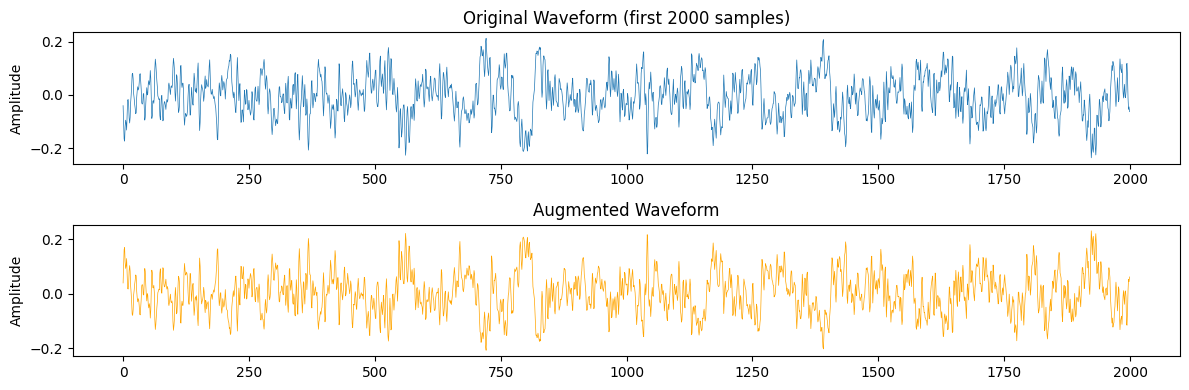

Augmentation pipeline ready ✓


In [6]:
class AudioAugmentations:
    """
    Stochastic augmentation pipeline following Table 1 of SemiSupCon paper.
    Each augmentation is applied with probability p.
    """
    
    def __init__(self, sr=SR, p=0.5):
        self.sr = sr
        self.p = p
    
    def gain(self, x):
        """Random gain between -15 and 5 dB."""
        if random.random() > self.p:
            return x
        gain_db = random.uniform(-15, 5)
        gain_linear = 10 ** (gain_db / 20)
        return x * gain_linear
    
    def polarity_inversion(self, x):
        """Flip polarity with probability p."""
        if random.random() > self.p:
            return x
        return -x
    
    def colored_noise(self, x):
        """Add colored noise (white, pink, or brown) with random SNR 3-30 dB."""
        if random.random() > self.p:
            return x
        
        snr_db = random.uniform(3, 30)
        noise_type = random.choice(['white', 'pink', 'brown'])
        
        # Generate white noise
        noise = torch.randn_like(x)
        
        if noise_type == 'pink':
            # Approximate pink noise via spectral shaping
            fft = torch.fft.rfft(noise)
            freqs = torch.arange(1, len(fft) + 1, dtype=torch.float32)
            fft = fft / torch.sqrt(freqs)
            noise = torch.fft.irfft(fft, n=len(x))
        elif noise_type == 'brown':
            # Brown noise: cumulative sum of white noise
            noise = torch.cumsum(noise, dim=0)
            noise = noise / noise.abs().max()  # Normalize
        
        # Scale noise to desired SNR
        signal_power = (x ** 2).mean()
        noise_power = (noise ** 2).mean()
        if noise_power > 0:
            snr_linear = 10 ** (snr_db / 10)
            scale = torch.sqrt(signal_power / (snr_linear * noise_power))
            noise = noise * scale
        
        return x + noise
    
    def _apply_biquad(self, x, b, a):
        """Apply a biquad filter using torchaudio."""
        # Use scipy-style filtering via convolution
        from scipy.signal import lfilter
        filtered = lfilter(b.numpy() if isinstance(b, torch.Tensor) else b,
                          a.numpy() if isinstance(a, torch.Tensor) else a,
                          x.numpy())
        return torch.from_numpy(filtered.copy()).float()
    
    def _design_lowpass(self, cutoff, sr):
        """Simple 2nd order Butterworth lowpass."""
        from scipy.signal import butter
        nyq = sr / 2
        normalized_cutoff = min(cutoff / nyq, 0.99)
        b, a = butter(2, normalized_cutoff, btype='low')
        return b, a
    
    def _design_highpass(self, cutoff, sr):
        """Simple 2nd order Butterworth highpass."""
        from scipy.signal import butter
        nyq = sr / 2
        normalized_cutoff = max(cutoff / nyq, 0.01)
        b, a = butter(2, normalized_cutoff, btype='high')
        return b, a
    
    def random_filter(self, x):
        """Apply random filter: lowpass, highpass, bandpass, or bandcut."""
        if random.random() > self.p:
            return x
        
        from scipy.signal import butter
        filter_type = random.choice(['lowpass', 'highpass', 'bandpass', 'bandstop'])
        nyq = self.sr / 2
        
        try:
            if filter_type == 'lowpass':
                cutoff = random.uniform(1000, 8000)
                b, a = butter(2, min(cutoff / nyq, 0.99), btype='low')
            elif filter_type == 'highpass':
                cutoff = random.uniform(100, 2000)
                b, a = butter(2, max(cutoff / nyq, 0.01), btype='high')
            elif filter_type == 'bandpass':
                low = random.uniform(200, 2000)
                high = random.uniform(low + 500, min(low + 5000, nyq - 1))
                b, a = butter(2, [low / nyq, high / nyq], btype='band')
            else:  # bandstop
                low = random.uniform(200, 2000)
                high = random.uniform(low + 500, min(low + 5000, nyq - 1))
                b, a = butter(2, [low / nyq, high / nyq], btype='bandstop')
            
            return self._apply_biquad(x, b, a)
        except Exception:
            return x  # Return unfiltered on error
    
    def pitch_shift(self, x):
        """Pitch shift by -4 to +4 semitones."""
        if random.random() > self.p:
            return x
        
        n_steps = random.uniform(-4, 4)
        x_np = x.numpy()
        shifted = librosa.effects.pitch_shift(
            y=x_np, sr=self.sr, n_steps=n_steps
        )
        return torch.from_numpy(shifted).float()
    
    def __call__(self, x):
        """Apply full augmentation chain."""
        x = self.gain(x)
        x = self.polarity_inversion(x)
        x = self.colored_noise(x)
        x = self.random_filter(x)
        x = self.pitch_shift(x)
        return x


# ── Test augmentation ──
augmenter = AudioAugmentations(sr=SR, p=0.5)

test_wave = dataset[0][0]
aug_wave = augmenter(test_wave)

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].plot(test_wave.numpy()[:2000], linewidth=0.5)
axes[0].set_title('Original Waveform (first 2000 samples)')
axes[0].set_ylabel('Amplitude')
axes[1].plot(aug_wave.numpy()[:2000], linewidth=0.5, color='orange')
axes[1].set_title('Augmented Waveform')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()
print('Augmentation pipeline ready ✓')

## 5. SampleCNN Encoder

In [7]:
class SampleCNNBlock(nn.Module):
    """Basic SampleCNN convolutional block: Conv1d + BN + ReLU + MaxPool."""
    
    def __init__(self, in_channels, out_channels, kernel_size=3, pool_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                             stride=1, padding=kernel_size // 2)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool1d(pool_size)
    
    def forward(self, x):
        return self.pool(self.relu(self.bn(self.conv(x))))


class SampleCNN(nn.Module):
    """
    SampleCNN encoder for raw audio waveforms.
    
    Architecture:
    - First layer: Conv1d with stride 3 for initial downsampling
    - 9 conv blocks: Conv1d(3) + BN + ReLU + MaxPool(3)
    - Global average pooling
    - Output: d_E = 512 dimensional embedding
    
    Input: (batch, n_samples) raw waveform
    Output: (batch, 512) embedding
    """
    
    def __init__(self, n_samples=N_SAMPLES, d_encoder=D_ENCODER):
        super().__init__()
        
        # First layer: strided convolution for initial downsampling
        self.first_conv = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=3, stride=3, padding=0),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True)
        )
        
        # Convolutional blocks
        channels = [128, 128, 128, 256, 256, 256, 256, 256, 512]
        self.blocks = nn.ModuleList()
        in_ch = 128
        for out_ch in channels:
            self.blocks.append(SampleCNNBlock(in_ch, out_ch, kernel_size=3, pool_size=3))
            in_ch = out_ch
        
        # Global average pooling
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        self.d_encoder = d_encoder
    
    def forward(self, x):
        # x: (batch, n_samples)
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (batch, 1, n_samples)
        
        x = self.first_conv(x)  # (batch, 128, n_samples//3)
        
        for block in self.blocks:
            x = block(x)
        
        x = self.gap(x)         # (batch, 512, 1)
        x = x.squeeze(-1)       # (batch, 512)
        
        return x


# ── Test encoder ──
encoder = SampleCNN().to(DEVICE)
test_input = torch.randn(4, N_SAMPLES).to(DEVICE)
test_output = encoder(test_input)
print(f'Encoder input:  {test_input.shape}')
print(f'Encoder output: {test_output.shape}')
print(f'Parameters: {sum(p.numel() for p in encoder.parameters()):,}')

Encoder input:  torch.Size([4, 59535])
Encoder output: torch.Size([4, 512])
Parameters: 1,432,704


## 6. Projection Head

In [8]:
class ProjectionHead(nn.Module):
    """
    2-layer MLP projection head.
    Maps encoder embeddings (d_E=512) to contrastive space (d_g=128).
    Applies L2 normalization to the output.
    """
    
    def __init__(self, d_encoder=D_ENCODER, d_proj=D_PROJ):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_encoder, d_encoder),
            nn.ReLU(inplace=True),
            nn.Linear(d_encoder, d_proj)
        )
    
    def forward(self, x):
        x = self.mlp(x)
        return F.normalize(x, dim=-1)  # L2 normalization


class SemiSupConModel(nn.Module):
    """Full model: SampleCNN encoder + Projection Head."""
    
    def __init__(self):
        super().__init__()
        self.encoder = SampleCNN()
        self.projector = ProjectionHead()
    
    def forward(self, x):
        h = self.encoder(x)     # (batch, 512)
        z = self.projector(h)   # (batch, 128)
        return h, z


# ── Test full model ──
model = SemiSupConModel().to(DEVICE)
h, z = model(test_input)
print(f'Encoder embedding h: {h.shape}')
print(f'Projection z:         {z.shape}')
print(f'z is L2-normalized:   {torch.allclose(z.norm(dim=-1), torch.ones(4).to(DEVICE), atol=1e-5)}')
print(f'Total parameters:     {sum(p.numel() for p in model.parameters()):,}')

Encoder embedding h: torch.Size([4, 512])
Projection z:         torch.Size([4, 128])
z is L2-normalized:   True
Total parameters:     1,761,024


## 7. Pérdida SemiSupCon (Equation 3)

$$\mathcal{L}_{sem} = \sum_{i \in I} \frac{-1}{|P(i)|} \sum_{p \in P(i)} \log \frac{\exp(z_i \cdot z_p / \tau)}{\sum_{k \neq i} \exp(z_i \cdot z_k / \tau)}$$

Where:
- For supervised samples $i \in \mathcal{S}$: $P(i)$ includes all samples with the same label **and** augmentation pair
- For unsupervised samples $i \in \mathcal{U}$: $P(i)$ includes only the augmentation pair

In [9]:
class SemiSupConLoss(nn.Module):
    """
    Semi-Supervised Contrastive Loss (SemiSupCon).
    
    For a batch of N samples, we generate 2N representations (2 augmented views).
    - Supervised samples: positives = same-class samples + augmentation pair
    - Unsupervised samples: positives = only augmentation pair
    
    Args:
        temperature: τ for scaling similarities
    """
    
    def __init__(self, temperature=TAU):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, z1, z2, labels, is_supervised):
        """
        Args:
            z1: (N, d) normalized projections from view 1
            z2: (N, d) normalized projections from view 2
            labels: (N,) genre labels (-1 for unsupervised)
            is_supervised: (N,) boolean mask
        
        Returns:
            Scalar loss
        """
        N = z1.size(0)
        device = z1.device
        
        # Concatenate both views: [z1_0, z1_1, ..., z1_N, z2_0, z2_1, ..., z2_N]
        z = torch.cat([z1, z2], dim=0)  # (2N, d)
        
        # Compute all pairwise similarities
        sim_matrix = torch.mm(z, z.t()) / self.temperature  # (2N, 2N)
        
        # Create self-mask (exclude diagonal)
        self_mask = ~torch.eye(2 * N, dtype=torch.bool, device=device)
        
        # ── Build positive mask ──
        # Augmentation pairs: (i, i+N) and (i+N, i) are always positive
        pos_mask = torch.zeros(2 * N, 2 * N, dtype=torch.bool, device=device)
        
        # Augmentation pair positives
        for i in range(N):
            pos_mask[i, i + N] = True      # z1_i <-> z2_i
            pos_mask[i + N, i] = True      # z2_i <-> z1_i
        
        # For supervised samples: same-class samples are also positives
        labels_ext = torch.cat([labels, labels], dim=0)  # (2N,)
        is_sup_ext = torch.cat([is_supervised, is_supervised], dim=0)  # (2N,)
        
        for i in range(2 * N):
            if is_sup_ext[i]:
                for j in range(2 * N):
                    if i != j and is_sup_ext[j] and labels_ext[i] == labels_ext[j]:
                        pos_mask[i, j] = True
        
        # ── Compute loss ──
        # For numerical stability
        logits_max, _ = sim_matrix.max(dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()
        
        # Denominator: sum over all negatives (everything except self)
        exp_logits = torch.exp(logits) * self_mask.float()
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)
        
        # Mean log-likelihood over positive pairs
        # Only consider samples with at least one positive
        pos_count = pos_mask.sum(dim=1).float()
        mask_valid = pos_count > 0
        
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1)
        mean_log_prob_pos = mean_log_prob_pos / (pos_count + 1e-12)
        
        # Loss: negative mean log-prob
        loss = -mean_log_prob_pos[mask_valid].mean()
        
        return loss


# ── Test loss ──
criterion = SemiSupConLoss(temperature=TAU)

# Fake data
fake_z1 = F.normalize(torch.randn(8, D_PROJ), dim=-1).to(DEVICE)
fake_z2 = F.normalize(torch.randn(8, D_PROJ), dim=-1).to(DEVICE)
fake_labels = torch.tensor([0, 0, 1, 1, -1, -1, -1, -1]).to(DEVICE)
fake_is_sup = torch.tensor([True, True, True, True, False, False, False, False]).to(DEVICE)

test_loss = criterion(fake_z1, fake_z2, fake_labels, fake_is_sup)
print(f'Test SemiSupCon loss: {test_loss.item():.4f}')
print(f'Loss is finite: {torch.isfinite(test_loss).item()} ✓')

Test SemiSupCon loss: 2.8090
Loss is finite: True ✓


## 8. Training Loop

In [10]:
def train_one_epoch(model, dataloader, augmenter, criterion, optimizer, device, epoch):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    n_batches = 0
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1:3d}', leave=False)
    
    for batch in pbar:
        waveforms, labels, is_supervised = batch
        
        # Generate two augmented views
        view1 = torch.stack([augmenter(w) for w in waveforms]).to(device)
        view2 = torch.stack([augmenter(w) for w in waveforms]).to(device)
        labels = labels.to(device)
        is_supervised = is_supervised.to(device)
        
        # Forward pass
        _, z1 = model(view1)
        _, z2 = model(view2)
        
        # Compute loss
        loss = criterion(z1, z2, labels, is_supervised)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / max(n_batches, 1)


# ── Setup training ──
model = SemiSupConModel().to(DEVICE)
augmenter = AudioAugmentations(sr=SR, p=0.5)
criterion = SemiSupConLoss(temperature=TAU)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Create dataloader with semi-supervised batch sampler
batch_sampler = SemiSupConBatchSampler(df_tracks, BATCH_SIZE, BS_RATIO)
train_loader = DataLoader(
    dataset,
    batch_sampler=batch_sampler,
    num_workers=0,  # Keep 0 for MPS compatibility
    pin_memory=False
)

print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Device: {DEVICE}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Starting training for {EPOCHS} epochs...\n')

# ── Training loop ──
loss_history = []
best_loss = float('inf')

for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(
        model, train_loader, augmenter, criterion, optimizer, DEVICE, epoch
    )
    loss_history.append(avg_loss)
    
    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, str(BASE_DIR / 'best_semisupcon.pt'))
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Best: {best_loss:.4f}')

print(f'\n✓ Training complete. Best loss: {best_loss:.4f}')

Model: 1,761,024 parameters
Device: mps
Batches per epoch: 15
Starting training for 50 epochs...



Epoch   1:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/50 | Loss: 4.0192 | Best: 4.0192


Epoch   2:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   3:   0%|          | 0/15 [00:00<?, ?it/s]

...

Epoch  47:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  48:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  49:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  50:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  50/50 | Loss: 2.8612 | Best: 2.7463

✓ Training complete. Best loss: 2.7463


## 9. Visualización de Loss

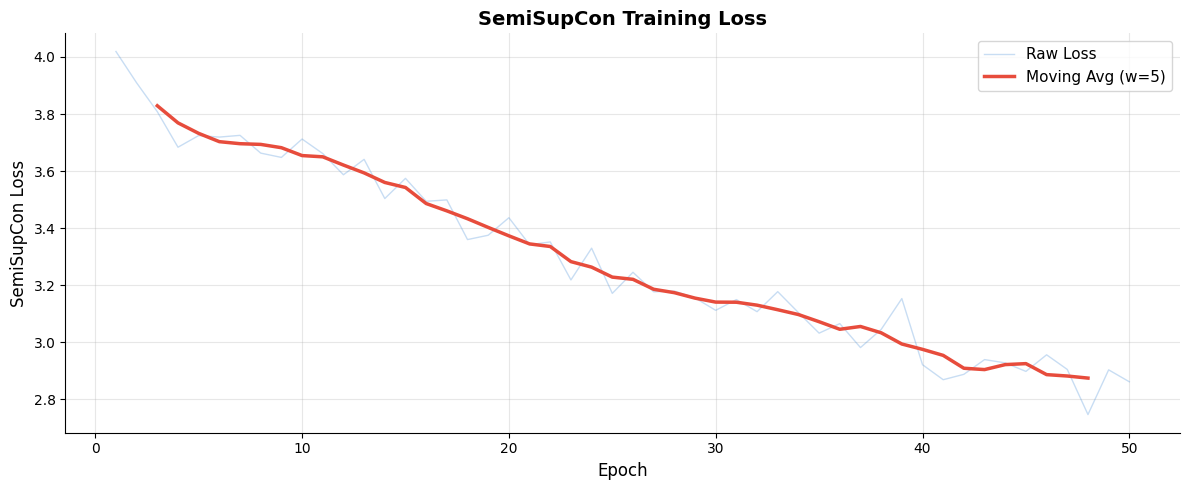

Initial loss:  4.0192
Final loss:    2.8612
Best loss:     2.7463
Reduction:     28.8%


In [11]:
def moving_average(data, window=5):
    """Compute moving average for smoothing."""
    if len(data) < window:
        return data
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window


fig, ax = plt.subplots(figsize=(12, 5))

epochs_range = range(1, len(loss_history) + 1)
ax.plot(epochs_range, loss_history, alpha=0.3, color='#4a90d9', linewidth=1, label='Raw Loss')

# Smoothed loss
if len(loss_history) >= 5:
    smoothed = moving_average(loss_history, window=5)
    ax.plot(range(3, 3 + len(smoothed)), smoothed, color='#e74c3c',
            linewidth=2.5, label='Moving Avg (w=5)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('SemiSupCon Loss', fontsize=12)
ax.set_title('SemiSupCon Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Initial loss:  {loss_history[0]:.4f}')
print(f'Final loss:    {loss_history[-1]:.4f}')
print(f'Best loss:     {min(loss_history):.4f}')
print(f'Reduction:     {(1 - loss_history[-1]/loss_history[0])*100:.1f}%')

## 10. Linear Probing (Evaluación)

Congelamos el encoder SampleCNN entrenado y entrenamos un MLP clasificador sobre los embeddings extraídos para evaluar la calidad de las representaciones aprendidas.

In [12]:
# ── Load best model ──
checkpoint = torch.load(str(BASE_DIR / 'best_semisupcon.pt'), map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"] + 1} (loss: {checkpoint["loss"]:.4f})')

# ── Freeze encoder ──
model.eval()
for param in model.encoder.parameters():
    param.requires_grad = False

print('Encoder frozen ✓')

Loaded best model from epoch 48 (loss: 2.7463)
Encoder frozen ✓


In [13]:
# ── Extract embeddings for ALL samples (using their actual labels) ──
print('Extracting embeddings...')

all_embeddings = []
all_labels = []

# Create a simple sequential dataloader for extraction
eval_dataset = FMAAudioDataset(
    df_tracks.assign(is_supervised=True)  # Use all labels for probing
)
eval_loader = DataLoader(eval_dataset, batch_size=16, shuffle=False, num_workers=0)

with torch.no_grad():
    for waveforms, labels, _ in tqdm(eval_loader, desc='Extracting'):
        waveforms = waveforms.to(DEVICE)
        h = model.encoder(waveforms)  # (batch, 512)
        all_embeddings.append(h.cpu())
        all_labels.append(labels)

X = torch.cat(all_embeddings, dim=0).numpy()  # (N, 512)
y = torch.cat(all_labels, dim=0).numpy()       # (N,)

print(f'Embeddings shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Unique labels: {np.unique(y)}')

Extracting embeddings...


Extracting:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings shape: (500, 512)
Labels shape: (500,)
Unique labels: [0 1 2 3 4 5 6 7]


In [14]:
# ── Train/test split for probing ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

num_classes = len(genre_to_idx)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Classes: {num_classes}')


# ── Probing MLP ──
class ProbingMLP(nn.Module):
    """2-layer MLP classifier for linear probing."""
    
    def __init__(self, d_input=D_ENCODER, d_hidden=256, n_classes=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_input, d_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(d_hidden, n_classes)
        )
    
    def forward(self, x):
        return self.mlp(x)


probe = ProbingMLP(D_ENCODER, 256, num_classes).to(DEVICE)
probe_optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
probe_criterion = nn.CrossEntropyLoss()

# ── Train probing classifier ──
print('\nTraining probing MLP...')
probe_losses = []
probe_accs = []

PROBE_EPOCHS = 100
PROBE_BATCH = 64

for epoch in range(PROBE_EPOCHS):
    probe.train()
    
    # Mini-batch training
    indices = torch.randperm(len(X_train_t))
    epoch_loss = 0
    n_batches = 0
    
    for start in range(0, len(indices), PROBE_BATCH):
        batch_idx = indices[start:start + PROBE_BATCH]
        x_batch = X_train_t[batch_idx]
        y_batch = y_train_t[batch_idx]
        
        logits = probe(x_batch)
        loss = probe_criterion(logits, y_batch)
        
        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    probe_losses.append(avg_loss)
    
    # Evaluate
    probe.eval()
    with torch.no_grad():
        test_logits = probe(X_test_t)
        test_preds = test_logits.argmax(dim=1).cpu().numpy()
        acc = accuracy_score(y_test, test_preds)
        probe_accs.append(acc)
    
    if (epoch + 1) % 20 == 0:
        print(f'  Probe Epoch {epoch+1:3d}/{PROBE_EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.3f}')

print(f'\n✓ Probing complete. Best accuracy: {max(probe_accs):.3f}')

Train: 350 | Test: 150
Classes: 8

Training probing MLP...
  Probe Epoch  20/100 | Loss: 1.1291 | Acc: 0.287
  Probe Epoch  40/100 | Loss: 0.5971 | Acc: 0.327
  Probe Epoch  60/100 | Loss: 0.3205 | Acc: 0.333
  Probe Epoch  80/100 | Loss: 0.1651 | Acc: 0.333
  Probe Epoch 100/100 | Loss: 0.1106 | Acc: 0.327

✓ Probing complete. Best accuracy: 0.360


In [15]:
# ── Final evaluation ──
probe.eval()
with torch.no_grad():
    test_logits = probe(X_test_t)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, test_preds)
f1_macro = f1_score(y_test, test_preds, average='macro')
f1_weighted = f1_score(y_test, test_preds, average='weighted')

print('=' * 50)
print('PROBING RESULTS')
print('=' * 50)
print(f'Accuracy:          {acc:.4f}')
print(f'F1 (macro):        {f1_macro:.4f}')
print(f'F1 (weighted):     {f1_weighted:.4f}')
print(f'Random baseline:   {1/num_classes:.4f}')
print(f'Improvement:       {acc / (1/num_classes):.1f}x over random')
print('=' * 50)

PROBING RESULTS
Accuracy:          0.3267
F1 (macro):        0.3165
F1 (weighted):     0.3173
Random baseline:   0.1250
Improvement:       2.6x over random


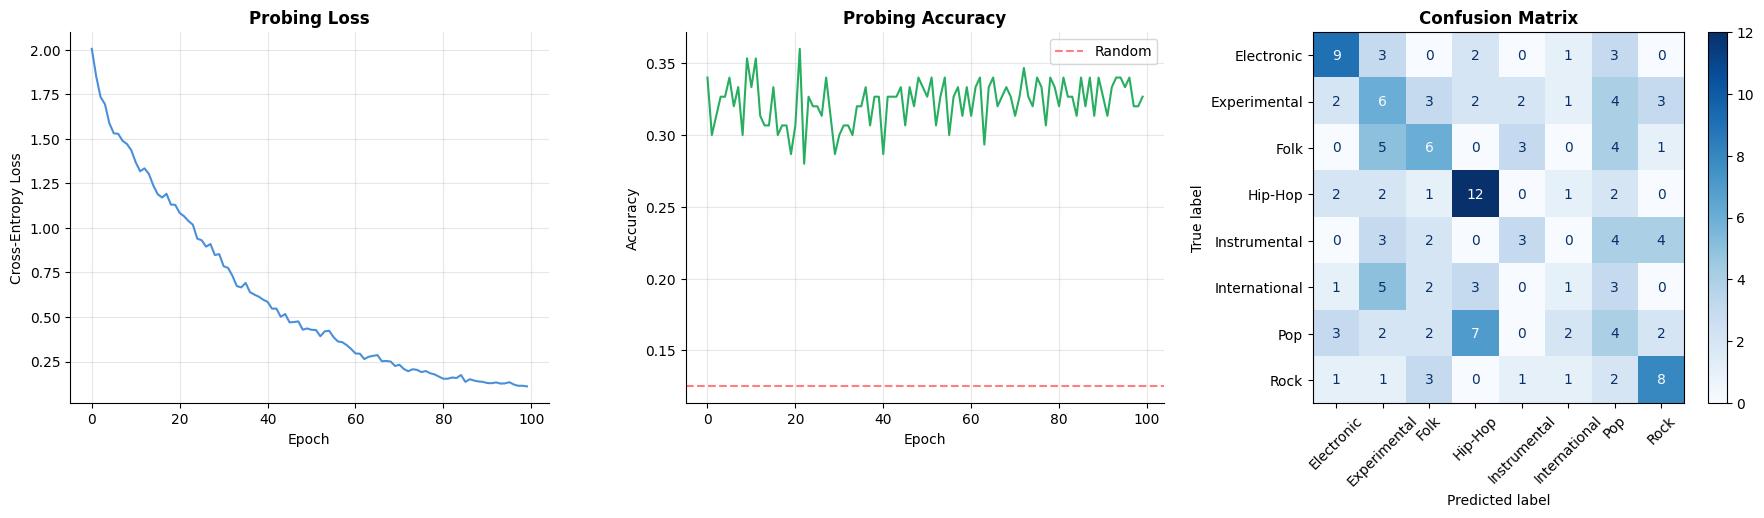


Per-class F1 scores:
  Electronic      0.500 ███████████████
  Experimental    0.240 ███████
  Folk            0.316 █████████
  Hip-Hop         0.522 ███████████████
  Instrumental    0.240 ███████
  International   0.091 ██
  Pop             0.167 █████
  Rock            0.457 █████████████


In [16]:
# ── Visualization: Probing metrics ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(probe_losses, color='#4a90d9', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Probing Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Accuracy curve
axes[1].plot(probe_accs, color='#27ae60', linewidth=1.5)
axes[1].axhline(y=1/num_classes, color='red', linestyle='--', alpha=0.5, label='Random')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Probing Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=genre_names)
disp.plot(ax=axes[2], cmap='Blues', values_format='d', xticks_rotation=45)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'probing_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class F1
print('\nPer-class F1 scores:')
f1_per_class = f1_score(y_test, test_preds, average=None)
for i, (genre, f1) in enumerate(zip(genre_names, f1_per_class)):
    bar = '█' * int(f1 * 30)
    print(f'  {genre:15s} {f1:.3f} {bar}')

---

## Resumen

Este notebook implementa un MVP del framework **SemiSupCon** (Guinot et al., ISMIR 2024):

1. **Datos**: 500 pistas de FMA Small, split 50/50 en supervisado/no-supervisado
2. **Encoder**: SampleCNN (10 bloques Conv1D, $d_E=512$)
3. **Projection Head**: MLP 2 capas ($512 \to 128$) + L2 norm
4. **Augmentations**: Gain, Polarity, Colored Noise, Filters, Pitch Shift
5. **Loss**: SemiSupCon loss ($\tau=0.1$) con positivos basados en clase (S) o augmentation (U)
6. **Evaluación**: Linear probing con MLP de 2 capas sobre embeddings congelados